## Train / validation / test split and baselines

I split the matches chronologically first, then I build a few simple baselines.
The baselines are useful because the machine-learning models shouldd be compared with something simple.

In [113]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    f1_score, 
    precision_score, 
    recall_score
)

In [114]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (PROCESSED_DATA_DIR / "featured_matches_2015_2025.csv")

matches = pd.read_csv(
    input_file, 
    parse_dates = ["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print("First date:", matches["Date"]. min())
print("Last date:", matches["Date"].max())

Dataset shape: (26536, 52)
First date: 2015-01-05 00:00:00
Last date: 2025-11-16 00:00:00


In [115]:
## did the target remain balanced even after feature engineering?
print(
    matches["Player1Won"].value_counts(normalize=True).sort_index()
)

Player1Won
0    0.502487
1    0.497513
Name: proportion, dtype: float64


A random split would mix old and future matches, so I use a chronological split:

- training: 2015-2022
- validation: 2023
- test: 2024-2025

The test set stays untouched until the final notebook.

In [116]:
validation_start = pd.Timestamp("2023-01-01")
test_start = pd.Timestamp("2024-01-01")

In [117]:
train_data = matches.loc[
    matches["Date"] < validation_start
].copy()

validation_data = matches.loc[
    (matches["Date"] >= validation_start) & 
    (matches["Date"] < test_start)
].copy()

test_data = matches.loc[
    matches["Date"] >= test_start
].copy()

In [118]:
split_summary = pd.DataFrame(
    {
        "Split": [
            "Training", 
            "Validation", 
            "Test"
        ],
        "NumberOfMatches": [
            len(train_data),
            len(validation_data), 
            len(test_data)
        ],
        "FirstDate": [
            train_data["Date"].min(), 
            validation_data["Date"].min(), 
            test_data["Date"].min()
        ],
        "LastDate": [
            train_data["Date"].max(),
            validation_data["Date"].max(),
            test_data["Date"].max()
        ], 
        "Player1WinProportion": [
            train_data["Player1Won"].mean(), 
            validation_data["Player1Won"].mean(), 
            test_data["Player1Won"].mean()
        ]
    }
)

split_summary

,Split,NumberOfMatches,FirstDate,LastDate,Player1WinProportion
0,Training,18810,2015-01-05,2022-11-20,0.498458
1,Validation,2607,2023-01-01,2023-12-31,0.475259
2,Test,5119,2024-01-01,2025-11-16,0.505372


In [119]:
assert train_data["Date"].max() < validation_data["Date"].min()
assert validation_data["Date"].max() < test_data["Date"].min()

assert (
    len(train_data)+len(validation_data)+len(test_data)
    == len(matches)
)

print("Chronological split validation passed.")

Chronological split validation passed.


In [120]:
 ## add split label
 ## the select function receives a list of condition 
 ## and a list of corresponding values. 
matches["DataSplit"] = np.select(
    [
        matches["Date"] < validation_start, 
        (
            (matches["Date"] >= validation_start)
            & (matches["Date"] < test_start)
        ), 
        matches["Date"] >= test_start
    ], 
    [
        "Training", 
        "Validation", 
        "Test"
    ], 
    default="Unknown"
)

In [121]:
print(matches["DataSplit"].value_counts())

assert matches["DataSplit"].ne("Unknown").all()

print("Every match received a split label.")

DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64
Every match received a split label.


In [122]:
target_column = "Player1Won"

y_train = train_data[target_column] ## correct results of training matches
y_validation = validation_data[target_column] ## correct results of validation matches 
y_test = test_data[target_column] ## correct results of the test matches

In [123]:
## decide the columns that can be used as model inputs 

excluded_columns = [
    "MatchID", 
    "Date", ## not needed bc there are other attributes
    "SourceYear", ## only identifies the source file 
    "ATP",
    "Location", ## contain many categories --> make the model too complicated
    "Tournament",## same as Location
    "Player1", ## better to avoid names, the model may memorize players
    "Player2", 
    "Player1Won", # answer we are predicted, cannot be included 
    "DataSplit"
    
]

## separate main features 

numeric_features = [
    "Player1Rank",
    "Player2Rank",
    "Player1Points",
    "Player2Points",

    "Player1MatchesBefore",
    "Player2MatchesBefore",
    "ExperienceDifference",

    "Player1WinRateBefore",
    "Player2WinRateBefore",
    "WinRateDifference",

    "Player1Recent5WinRate",
    "Player2Recent5WinRate",
    "Recent5WinRateDifference",

    "Player1SurfaceMatchesBefore",
    "Player2SurfaceMatchesBefore",
    "SurfaceMatchesDifference",

    "Player1SurfaceWinRateBefore",
    "Player2SurfaceWinRateBefore",
    "SurfaceWinRateDifference",

    "H2HMatchesBefore",
    "Player1H2HWinRateBefore",
    "Player2H2HWinRateBefore",
    "DifferenceH2HWinRateBefore",

    "Player1DaysSinceLastMatch",
    "Player2DaysSinceLastMatch",
    "DaysSinceLastMatchDifference",

    "MissingPlayer1DaysSinceLastMatch",
    "MissingPlayer2DaysSinceLastMatch",

    "RankDifference",
    "PointsDifference"
]

categorical_features = [
    "Series", ## tournament series, e.g. Grand Slam, ATP 1000, etc.
    "Court", 
    "Surface", 
    "Round", ##tournament phase in which the match is played
    "Best of" ## tot sets for the match
    ##set as categorical because they are not continuous values, but rather discrete categories
]

main_features = numeric_features + categorical_features

## check that all the columns exist
missing_model_columns = [
    column
    for column in main_features
    if column not in matches.columns
]

print("Missing model columns:", missing_model_columns)
print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("Total model features:", len(main_features))


Missing model columns: []
Number of numerical features: 30
Number of categorical features: 5
Total model features: 35


In [125]:
## Optional betting features.
## They are pre-match information, but I keep them out of the main experiment
## so that the model is based mainly on the tennis features created above.

betting_features = [
    "Player1B365Odds",
    "Player2B365Odds",
    "Player1PSOdds",
    "Player2PSOdds",
    "Player1MaxOdds",
    "Player2MaxOdds",
    "Player1AvgOdds",
    "Player2AvgOdds"
]

In [126]:
X_train = train_data[main_features].copy()

X_validation = validation_data[main_features].copy()

X_test = test_data[main_features].copy()

In [127]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print( "X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)


X_train shape: (18810, 35)
y_train shape: (18810,)
X_validation shape: (2607, 35)
y_validation shape: (2607,)
X_test shape (5119, 35)
y_test shape (5119,)


In [128]:
assert len(X_train) == len(y_train)

assert len(X_validation) == len(y_validation)

assert len(X_test) == len(y_test)

print("Feature and target dimensions are consistent.")

Feature and target dimensions are consistent.


In [129]:
training_missing_values = (
    X_train.isna().sum().sort_values(ascending=False)
)

training_missing_values[
    training_missing_values > 0 
]

DaysSinceLastMatchDifference    577
Player2DaysSinceLastMatch       328
Player1DaysSinceLastMatch       317
Best of                          15
dtype: int64

Replace missing values for both categorical and numerical features. For numerical features replace missing values withe the median calculated only from the training set. We chose the medaian instead of the mean, because it is less sensitive to extreme values.  

In [130]:
numeric_medians= X_train[numeric_features].median()

X_train[numeric_features] = (
    X_train[numeric_features]
    .fillna(numeric_medians)
)

X_validation[numeric_features] = (
    X_validation[numeric_features] 
    .fillna(numeric_medians)
)

X_test[numeric_features] = (
    X_test[numeric_features]
    .fillna(numeric_medians)
)


In [131]:
categorical_modes = {}

for column in categorical_features:
    training_mode = X_train[column].mode().iloc[0]
    categorical_modes[column] = training_mode
    
    X_train[column] = X_train[column].fillna(training_mode)
    X_validation[column] = X_validation[column].fillna(training_mode)
    X_test[column] = X_test[column].fillna(training_mode)

In [132]:
print("Training missing values:", X_train.isna().sum().sum())
print("Validation missing values:", X_validation.isna().sum().sum())
print("Test missing values:", X_test.isna().sum().sum())

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("Missing-value treatment completed.")

Training missing values: 0
Validation missing values: 0
Test missing values: 0
Missing-value treatment completed.


Questa scelta:

handle_unknown="ignore"

è importante.

Immagina che nel validation set compaia una categoria che per qualche motivo non era presente nel training. Senza questa opzione il programma potrebbe andare in errore.

È anche la stessa impostazione usata nel notebook del corso.

In [133]:
one_hot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

one_hot_encoder.fit(
    X_train[categorical_features]
)

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infreque

In [134]:
for feature, categories in zip(
    categorical_features,
    one_hot_encoder.categories_
):
    print(feature, "->", categories)

Series -> ['ATP250' 'ATP500' 'Grand Slam' 'Masters 1000' 'Masters Cup']
Court -> ['Indoor' 'Outdoor']
Surface -> ['Clay' 'Grass' 'Hard']
Round -> ['1st Round' '2nd Round' '3rd Round' '4th Round' 'Quarterfinals'
 'Round Robin' 'Semifinals' 'The Final']
Best of -> [3. 5.]


In [135]:
train_categorical_encoded = one_hot_encoder.transform(
    X_train[categorical_features]
)

validation_categorical_encoded = one_hot_encoder.transform(
    X_validation[categorical_features]
)

test_categorical_encoded = one_hot_encoder.transform(
    X_test[categorical_features]   
)

In [136]:
encoded_feature_names = (
    one_hot_encoder.get_feature_names_out(
        categorical_features
    )
)

print(encoded_feature_names)
print("Number of encoded categorical features:", len(encoded_feature_names))

['Series_ATP250' 'Series_ATP500' 'Series_Grand Slam' 'Series_Masters 1000'
 'Series_Masters Cup' 'Court_Indoor' 'Court_Outdoor' 'Surface_Clay'
 'Surface_Grass' 'Surface_Hard' 'Round_1st Round' 'Round_2nd Round'
 'Round_3rd Round' 'Round_4th Round' 'Round_Quarterfinals'
 'Round_Round Robin' 'Round_Semifinals' 'Round_The Final' 'Best of_3.0'
 'Best of_5.0']
Number of encoded categorical features: 20


In [137]:
X_train_categorical = pd.DataFrame(
    train_categorical_encoded,
    columns = encoded_feature_names,
    index = X_train.index
)  

X_validation_categorical = pd.DataFrame(
    validation_categorical_encoded,
    columns = encoded_feature_names,
    index = X_validation.index
)

X_test_categorical = pd.DataFrame(
    test_categorical_encoded,
    columns = encoded_feature_names,
    index = X_test.index
)


In [138]:
X_train_processed = pd.concat(
    [
        X_train[numeric_features],
        X_train_categorical
    ],
    axis=1
)

X_validation_processed = pd.concat(
    [
        X_validation[numeric_features],
        X_validation_categorical
    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test[numeric_features],
        X_test_categorical
    ],
    axis=1
)


In [139]:
print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed validation shape:",
    X_validation_processed.shape
)

print(
    "Processed test shape:",
    X_test_processed.shape
)

assert (
    list(X_train_processed.columns)
    == list(X_validation_processed.columns)
)

assert (
    list(X_train_processed.columns)
    == list(X_test_processed.columns)
)

assert X_train_processed.isna().sum().sum() == 0
assert X_validation_processed.isna().sum().sum() == 0
assert X_test_processed.isna().sum().sum() == 0

print("Preprocessing validation passed.")

Processed training shape: (18810, 50)
Processed validation shape: (2607, 50)
Processed test shape: (5119, 50)
Preprocessing validation passed.


In [140]:
def evaluate_predictions (
    y_true, # contains real match results
    y_pred, # contains predicted match results
    model_name
):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred), 
        "BalancedAccuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division = 0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }
    
    return pd.DataFrame([results])

In [141]:
## define the baseline using majority voting 

majority_class = y_train.mode().iloc[0] ## mode returns the most freq value
print("Majority training class:", majority_class)

Majority training class: 0


In [142]:
majority_predictions = np.full( # full creates an array where every value is identical
    shape = len(validation_data),
    fill_value = majority_class
)

In [143]:
majority_results = evaluate_predictions(
    y_true = y_validation, 
    y_pred = majority_predictions, 
    model_name = "Majority class"
)

majority_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Majority class,0.524741,0.5,0.0,0.0,0.0


In [144]:
## define baseline using better-ranked player

ranking_predictions = np.where(
    validation_data["RankDifference"] > 0, 
    1, ## predict 1 when player1 is better ranked
    0
)

equal_rank = (
    validation_data["RankDifference"] == 0
)

ranking_predictions[equal_rank] = np.where(
    validation_data.loc[
        equal_rank, 
        "PointsDifference"
    ] >= 0, 
    1, # predict player1 when player1 has at least as many points
    0
)

ranking_results = evaluate_predictions (
    y_true = y_validation, 
    y_pred = ranking_predictions, 
    model_name = "Better-ranked player"
)

ranking_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Better-ranked player,0.640199,0.640648,0.614973,0.649718,0.631868


In [145]:
## baseline based on ranking points

points_predictions = np.where(
    validation_data["PointsDifference"] >= 0, 
    1, # when player1 has more points than player2
    0
)

points_results = evaluate_predictions(
    y_true = y_validation, 
    y_pred = points_predictions, 
    model_name = "More ranking points"
)

points_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,More ranking points,0.626007,0.626592,0.600152,0.638418,0.618694


In [146]:
## baseline using historical win rate

win_rate_predictions = np.where(
    validation_data["WinRateDifference"] >= 0, 
    1, ## player1 has an eq or greater prev win rate
    0
)

win_rate_results = evaluate_predictions(
    y_true = y_validation, 
    y_pred = win_rate_predictions,
    model_name = "Higher previous win rate"
)

win_rate_results 

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Higher previous win rate,0.607979,0.608424,0.582635,0.617433,0.59953


In [147]:
## baseline based on the recent win rate 

recent_form_predictions = np.where(
    validation_data["Recent5WinRateDifference"]>= 0,
    1,
    0
)

recent_form_results = evaluate_predictions(
    y_true = y_validation, 
    y_pred = recent_form_predictions, 
    model_name = "Better recent win rate"
)

recent_form_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Better recent win rate,0.549674,0.557169,0.519219,0.708636,0.599317


In [148]:
## combine all baseline results 

baseline_results = pd.concat(
    [
        majority_results, 
        ranking_results, 
        points_results, 
        win_rate_results, 
        recent_form_results
    ],
    ignore_index = True
)

baseline_results = baseline_results.sort_values(
    by= "Accuracy", 
    ascending= False
).reset_index(drop=True)

baseline_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Better-ranked player,0.640199,0.640648,0.614973,0.649718,0.631868
1,More ranking points,0.626007,0.626592,0.600152,0.638418,0.618694
2,Higher previous win rate,0.607979,0.608424,0.582635,0.617433,0.599530
3,Better recent win rate,0.549674,0.557169,0.519219,0.708636,0.599317
4,Majority class,0.524741,0.500000,0.000000,0.000000,0.000000


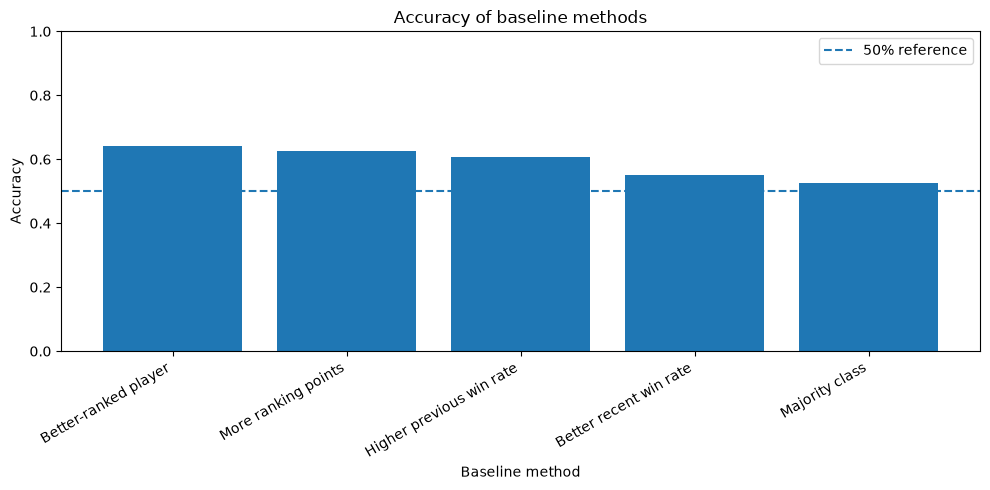

In [149]:
## create a baseline accuracy graph 

plt.figure(figsize =(10, 5))

plt.bar( ## to create a bar char 
    baseline_results["Model"],
    baseline_results["Accuracy"]
)

plt.axhline(  # draws an horizontal ref line at 50% accuracy
    y=0.5, 
    linestyle = "--",
    label = "50% reference"
)

plt.title("Accuracy of baseline methods")

plt.xlabel("Baseline method")
plt.ylabel("Accuracy")

plt.ylim(0, 1) ## vertical axis accuracy range

plt.xticks(
    rotation = 30, 
    ha= "right"
)

plt.legend()
plt.tight_layout() # prevent labels from being cut off
plt.show()

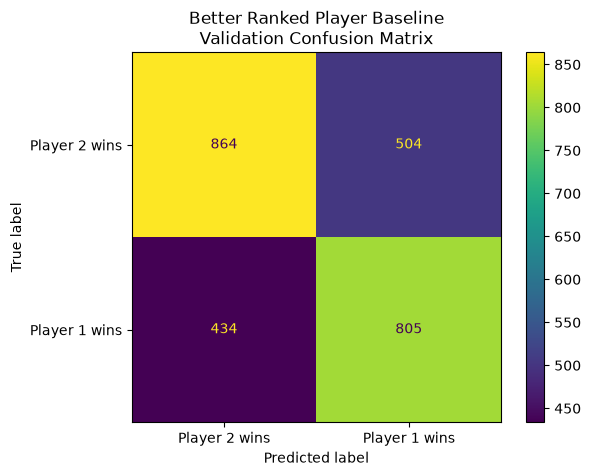

In [150]:
ConfusionMatrixDisplay.from_predictions(
    y_validation, 
    ranking_predictions, 
    display_labels=[
        "Player 2 wins",
        "Player 1 wins"
    ],
    values_format = "d"
)

plt.title(
    "Better Ranked Player Baseline\n"
    "Validation Confusion Matrix"
)

plt.show()

Our previous result table reports precision and recall considering:

Player1Won = 1

as the positive class.

The classification report allows you to verify whether prediction quality is similar for Player 1 and Player 2.

In [151]:
print(
    classification_report( 
        y_validation,
        ranking_predictions,
        target_names=[
            "Player 2 wins",
            "Player 1 wins"
        ],
        zero_division = 0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.67      0.63      0.65      1368
Player 1 wins       0.61      0.65      0.63      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



In [152]:
## copy of the validation matches 
validation_analysis = validation_data[
    [
        "MatchID",
        "Date",
        "Tournament",
        "Surface",
        "Round",
        "Player1",
        "Player2",
        "Player1Rank",
        "Player2Rank",
        "RankDifference",
        "Player1Won"
    ]
].copy()

## add prediction as feature
validation_analysis["RankingPrediction"] = ranking_predictions

## add a column to tell if prediction was correct
validation_analysis["PredictionCorrect"] = (
    validation_analysis["Player1Won"] ==
    validation_analysis["RankingPrediction"]
)

##check the proportion 
validation_analysis["PredictionCorrect"].value_counts(normalize=True)

## display incorrect predictions 
validation_analysis.loc[
    ~validation_analysis["PredictionCorrect"]
].head(20)
## these are the matches where the worse-ranked player won
    

,MatchID,Date,Tournament,Surface,Round,Player1,Player2,Player1Rank,Player2Rank,RankDifference,Player1Won,RankingPrediction,PredictionCorrect
18814,18814,2023-01-02,Adelaide International 1,Hard,1st Round,Cressy M.,Kokkinakis T.,34.0,93.0,59.0,0,1,False
18815,18815,2023-01-02,Adelaide International 1,Hard,1st Round,Rune H.,Nishioka Y.,11.0,36.0,25.0,0,1,False
18816,18816,2023-01-02,Adelaide International 1,Hard,1st Round,Auger-Aliassime F.,Popyrin A.,6.0,120.0,114.0,0,1,False
18817,18817,2023-01-02,Adelaide International 1,Hard,1st Round,Safiullin R.,Ymer M.,88.0,69.0,-19.0,1,0,False
18819,18819,2023-01-02,Maharashtra Open,Hard,1st Round,Zapata Miralles B.,Carballes Baena R.,72.0,74.0,2.0,0,1,False
18820,18820,2023-01-02,Maharashtra Open,Hard,1st Round,Cecchinato M.,Basilashvili N.,101.0,91.0,-10.0,1,0,False
18821,18821,2023-01-02,Maharashtra Open,Hard,1st Round,Molcan A.,Djere L.,50.0,70.0,20.0,0,1,False
18822,18822,2023-01-02,Maharashtra Open,Hard,1st Round,Munar J.,Griekspoor T.,58.0,95.0,37.0,0,1,False
18824,18824,2023-01-03,Adelaide International 1,Hard,1st Round,Bautista Agut R.,Rublev A.,21.0,8.0,-13.0,1,0,False
18832,18832,2023-01-03,Maharashtra Open,Hard,1st Round,Ymer E.,Marterer M.,127.0,159.0,32.0,0,1,False


In [153]:
# compare ranking difference for correct and wrong predictions

validation_analysis.groupby("PredictionCorrect")["RankDifference"].describe()

validation_analysis[
    "AbsoluteRankDifference"
    ] = validation_analysis[
        "RankDifference"
        ].abs()
    
validation_analysis.groupby(
    "PredictionCorrect"
)["AbsoluteRankDifference"].describe()

,count,mean,std,min,25%,50%,75%,max
PredictionCorrect,,,,,,,,
False,938.0,60.113006,87.269098,1.0,16.0,37.0,69.0,930.0
True,1669.0,113.931096,264.692948,1.0,23.0,48.0,95.0,4911.0


In [154]:
## save split dataset

split_output_file = (
    PROCESSED_DATA_DIR / "feature_split_matches.csv"
)

matches.to_csv(split_output_file, index = False)

print(
    "Split dataset saved to:",
    split_output_file.resolve()
)

Split dataset saved to: C:\Users\User\Downloads\project_ai\data\processed\feature_split_matches.csv


In [155]:
baseline_output_file = (
    PROCESSED_DATA_DIR / "validation_baseline.csv"
)

baseline_results.to_csv(
    baseline_output_file, 
    index = False
)

print(
    "Baseline results saved to:",
    baseline_output_file.resolve()
)

Baseline results saved to: C:\Users\User\Downloads\project_ai\data\processed\validation_baseline.csv


In [156]:
print("Training matches:", len(train_data))
print("Validation matches:", len(validation_data))
print("Test matches:", len(test_data))

print("\nValidation baseline results: ")
print(baseline_results)

print("\nBest validation baseline:")
print(baseline_results.iloc[0])

Training matches: 18810
Validation matches: 2607
Test matches: 5119

Validation baseline results: 
                      Model  Accuracy  BalancedAccuracy  Precision    Recall  \
0      Better-ranked player  0.640199          0.640648   0.614973  0.649718   
1       More ranking points  0.626007          0.626592   0.600152  0.638418   
2  Higher previous win rate  0.607979          0.608424   0.582635  0.617433   
3    Better recent win rate  0.549674          0.557169   0.519219  0.708636   
4            Majority class  0.524741          0.500000   0.000000  0.000000   

         F1  
0  0.631868  
1  0.618694  
2  0.599530  
3  0.599317  
4  0.000000  

Best validation baseline:
Model               Better-ranked player
Accuracy                        0.640199
BalancedAccuracy                0.640648
Precision                       0.614973
Recall                          0.649718
F1                              0.631868
Name: 0, dtype: object


In [157]:
## final summary
print(split_summary)

print(
    baseline_results[
        [
            "Model",
            "Accuracy",
            "BalancedAccuracy",
            "Precision",
            "Recall",
            "F1"
        ]
    ]
)

print(
    validation_analysis.groupby(
        "PredictionCorrect"
    )["AbsoluteRankDifference"].describe()
)

        Split  NumberOfMatches  FirstDate   LastDate  Player1WinProportion
0    Training            18810 2015-01-05 2022-11-20              0.498458
1  Validation             2607 2023-01-01 2023-12-31              0.475259
2        Test             5119 2024-01-01 2025-11-16              0.505372
                      Model  Accuracy  BalancedAccuracy  Precision    Recall  \
0      Better-ranked player  0.640199          0.640648   0.614973  0.649718   
1       More ranking points  0.626007          0.626592   0.600152  0.638418   
2  Higher previous win rate  0.607979          0.608424   0.582635  0.617433   
3    Better recent win rate  0.549674          0.557169   0.519219  0.708636   
4            Majority class  0.524741          0.500000   0.000000  0.000000   

         F1  
0  0.631868  
1  0.618694  
2  0.599530  
3  0.599317  
4  0.000000  
                    count        mean         std  min   25%   50%   75%  \
PredictionCorrect                                          